<a href="https://colab.research.google.com/github/Sj-kronton/IA_2025/blob/main/aprendizajesinsupervizado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##K-means
metodo de agrupamiento que dirije un conjunto de datos en grupos o clusteres a partir de centroides

##Practica

Analizar el archivo analisis.csv donde se evalua a la luz del "Ocean:Te big five" aspectos de la personalidad de diferentes figuras publicas en twitter


* Usuario: nombre de la figura publica en twitter
* "op": Opennes to experience
* "co": Conscientinousness (buena forma de escribir)
* "ex": extraversion, grado de timidez
* "ag": agreebleness
* "ne": neuroticism
* wordcount: cantidad de palabras promedio usadas en los tweets
* categoria: actividad laborar del usuario

###Categorias
1. actor/actriz
2. cantante
3. modelos
4. tv, series
5. radio
6. tecnologia
7. deportes
8. politica
9. escritores

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min

%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
plt.rcParams["figure.figsize"]=(16,9)
plt.style.use("ggplot")

In [5]:
dataframe=pd.read_csv("analisis.csv")
dataframe.head()

,usuario,op,co,ex,ag,ne,wordcount,categoria
0,3gerardpique,34.297953,28.148819,41.948819,29.370315,9.841575,37.0945,7
1,aguerosergiokun,44.986842,20.525865,37.938947,24.279098,10.362406,78.7970,7
2,albertochicote,41.733854,13.745417,38.999896,34.645521,8.836979,49.2604,4
3,AlejandroSanz,40.377154,15.377462,52.337538,31.082154,5.032231,80.4538,2
4,alfredocasero1,36.664677,19.642258,48.530806,31.138871,7.305968,47.0645,4


In [6]:
dataframe.describe()

,op,co,ex,ag,ne,wordcount,categoria
count,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000
mean,44.414591,22.977135,40.764428,22.918528,8.000098,98.715484,4.050000
std,8.425723,5.816851,7.185246,7.657122,3.039248,44.714071,2.658839
min,30.020465,7.852756,18.693542,9.305985,1.030213,5.020800,1.000000
25%,38.206484,19.740299,36.095722,17.050993,6.086144,66.218475,2.000000
50%,44.507091,22.466718,41.457492,21.384554,7.839722,94.711400,3.500000
75%,49.365923,26.091606,45.197769,28.678866,9.758189,119.707925,7.000000
max,71.696129,49.637863,59.824844,40.583162,23.978462,217.183200,9.000000


In [7]:
dataframe.groupby("categoria").size()

,0
categoria,
1,27
2,34
3,9
4,19
5,4
6,8
7,17
8,16
9,6


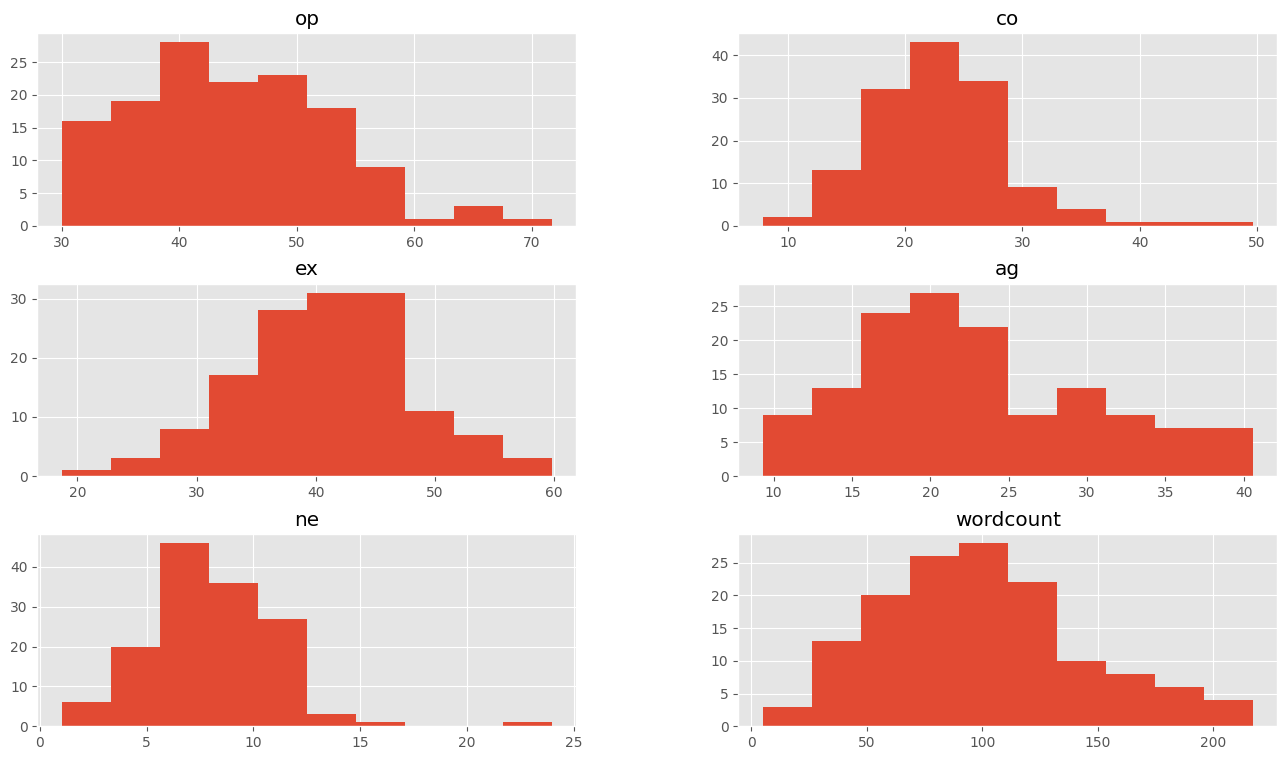

In [8]:
dataframe.drop(columns=["categoria"]).hist()
plt.show()

se seleccionara como dimensiones op,ex y ag. Se cruzara con el fin de encontrar alguna pista de agrupacion y relacion entre categorias

* Para paletas de colores: plasma, cividis o hsv

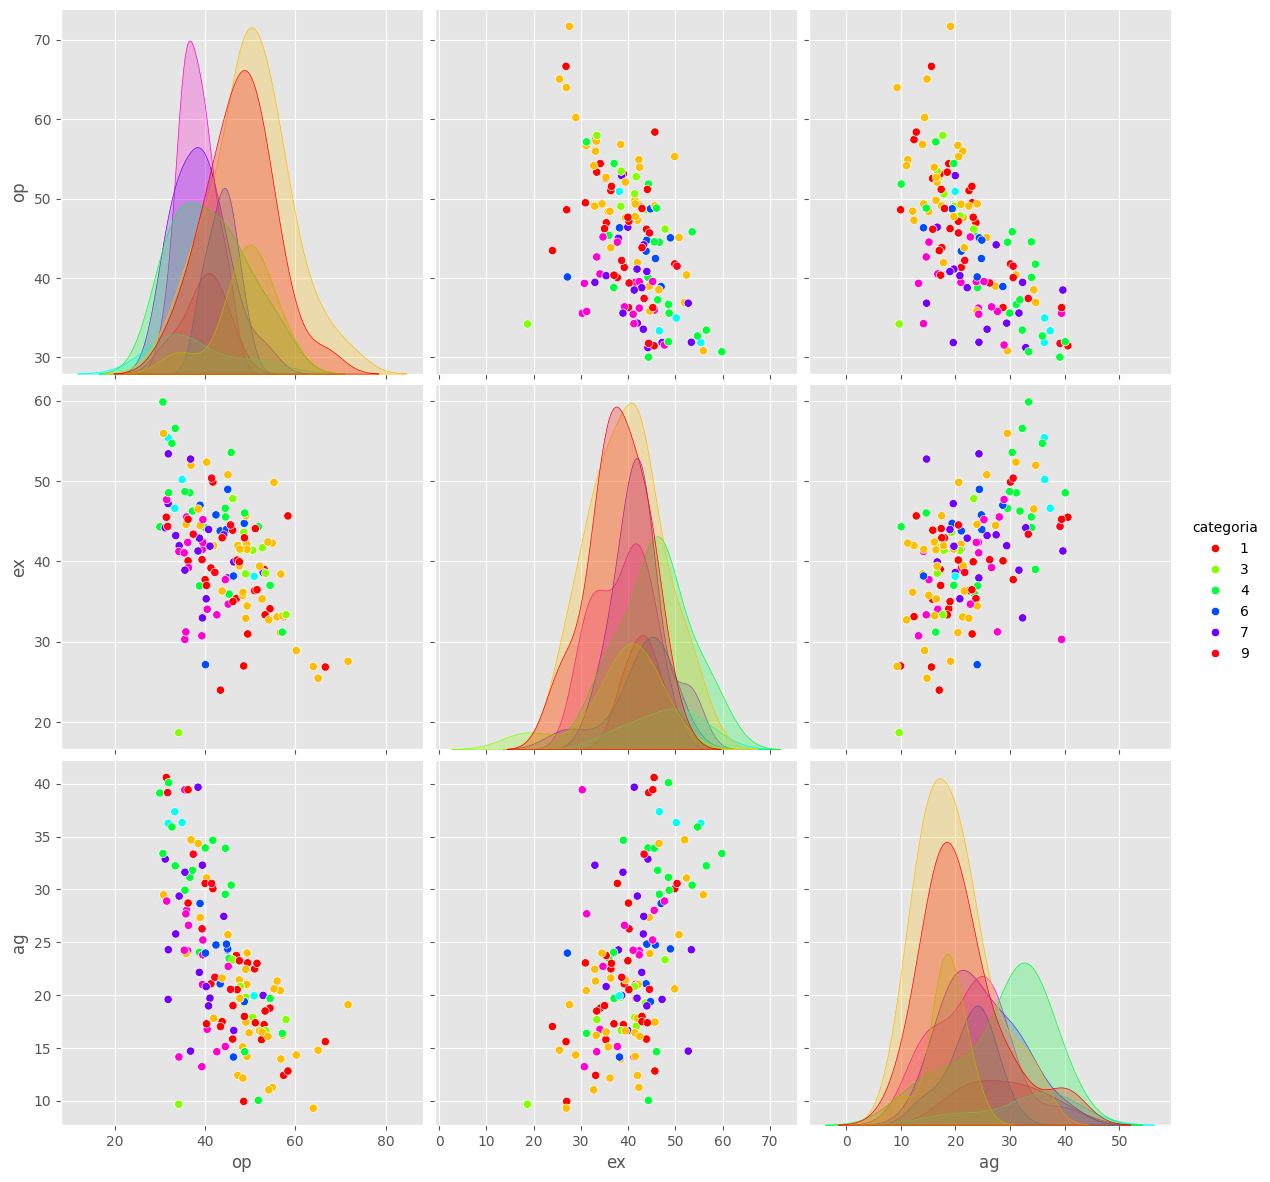

In [9]:
sb.pairplot(dataframe.dropna(),hue="categoria", height=4, vars=["op", "ex", "ag"], kind="scatter", palette="hsv")

In [10]:
#2d no da resultados claro, se intentara graficando en 3d

#se concreta la estructura de datos que se empleara para alimentar el algoritmo. se cargan las columnas op, ex y ag en la variable X

X=np.array(dataframe[["op","ex","ag"]])
y=np.array(dataframe["categoria"])
X.shape

(140, 3)

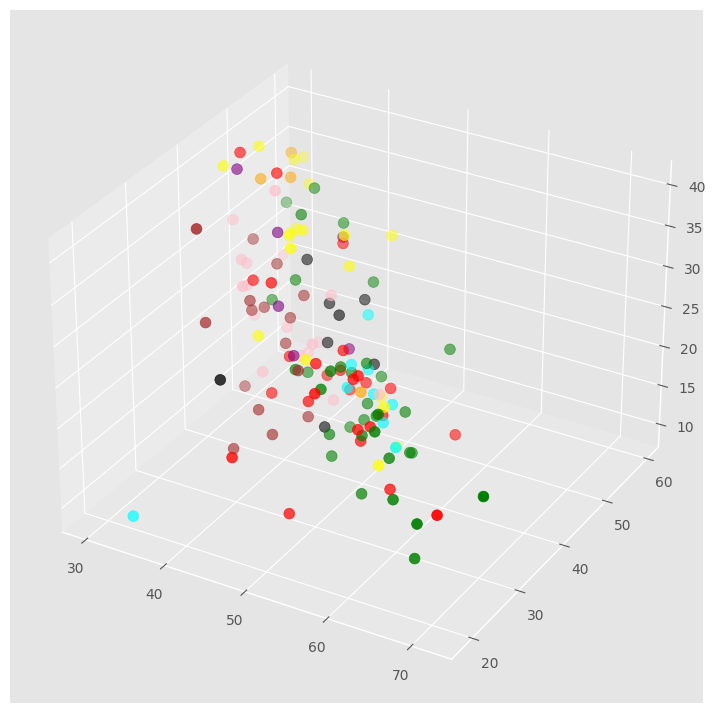

In [11]:
fig=plt.figure()
ax=fig.add_subplot(111, projection="3d")
colores=["blue","red","green","cyan","yellow","orange","black","pink","brown","purple"]
asignar=[]
for row in y:
    asignar.append(colores[row])
ax.scatter(X[:,0],X[:,1],X[:,2],c=asignar, s=60)
plt.show()

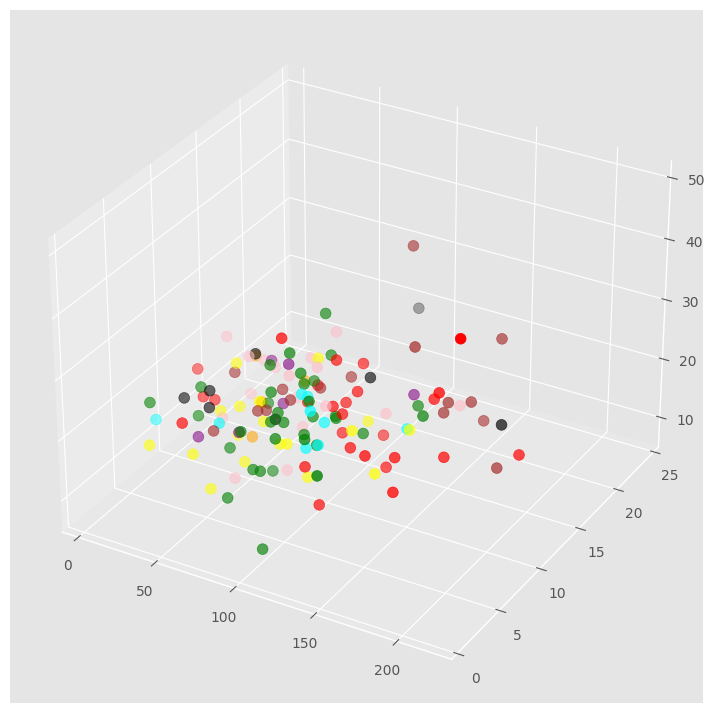

In [12]:
X=np.array(dataframe[["wordcount","ne","co"]])
y=np.array(dataframe["categoria"])
X.shape

fig=plt.figure()
ax=fig.add_subplot(111, projection="3d")
colores=["blue","red","green","cyan","yellow","orange","black","pink","brown","purple"]
asignar=[]
for row in y:
    asignar.append(colores[row])
ax.scatter(X[:,0],X[:,1],X[:,2],c=asignar, s=60)
plt.show()

##1. clusterizacion

obtener la cantidad de centroides - Obtener el valor de K
se empleara la metodologia de "punto de codo" para hallar la cantidad de centroides

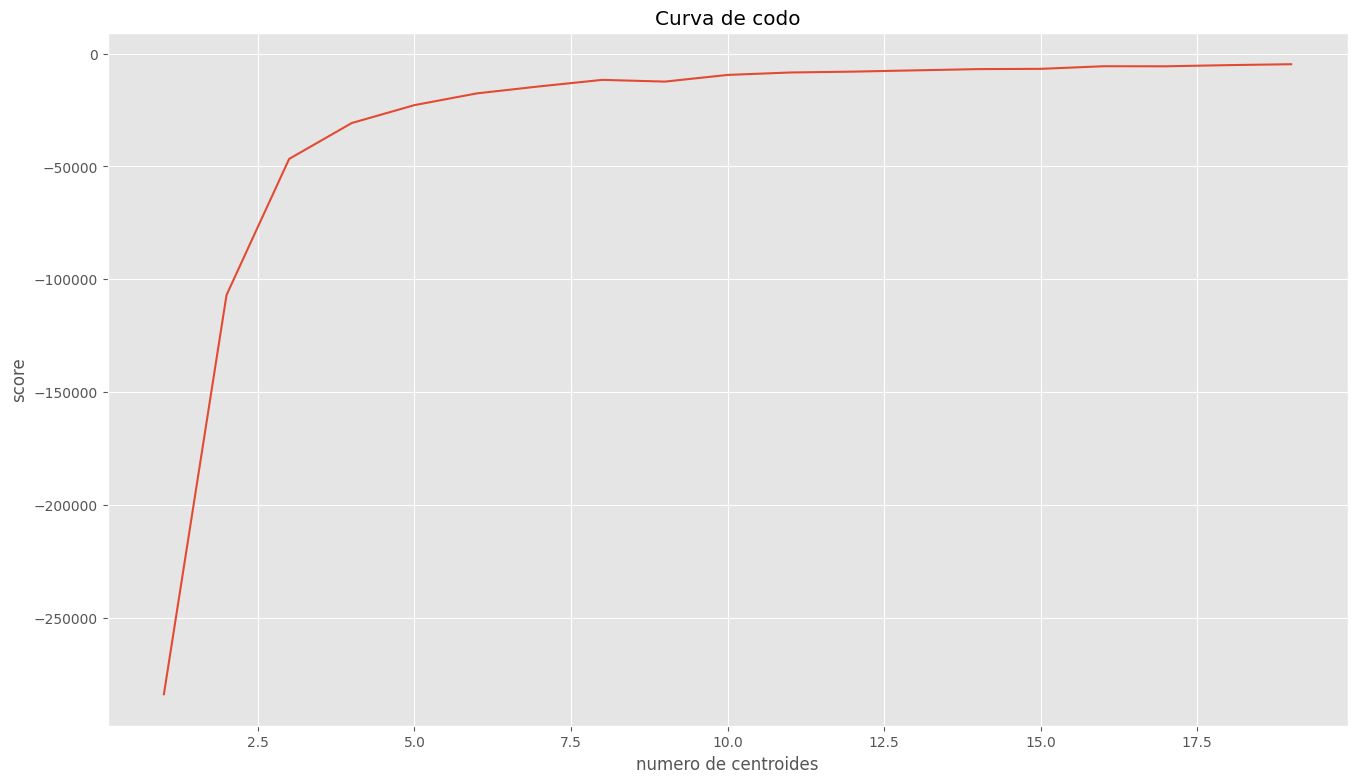

In [13]:
Nc=range(1,20)
kmeans=[KMeans(n_clusters=i) for i in Nc]
kmeans

score=[kmeans[i].fit(X).score(X) for i in range(len(kmeans))]
score
plt.plot(Nc,score)
plt.xlabel("numero de centroides")
plt.ylabel("score")
plt.title("Curva de codo")
plt.show()

Debido a lo observado, se elije a k=5, porque a partir de ese punto la curva es suave

##2. ejecucion de K-MEAN

obtener la ubicacion de los 5 centroides

In [14]:
kmeans=KMeans(n_clusters=5).fit(X)
centroids=kmeans.cluster_centers_
print(centroids)

[[ 44.71937059   7.63318615  20.54799994]
 [116.72868571   7.82717446  23.26567429]
 [ 85.26514348   7.98923483  23.15156087]
 [164.3119619    8.79072981  24.91348767]
 [210.364325     8.606031    28.9283265 ]]


Insertar los puntos en grafica 3d

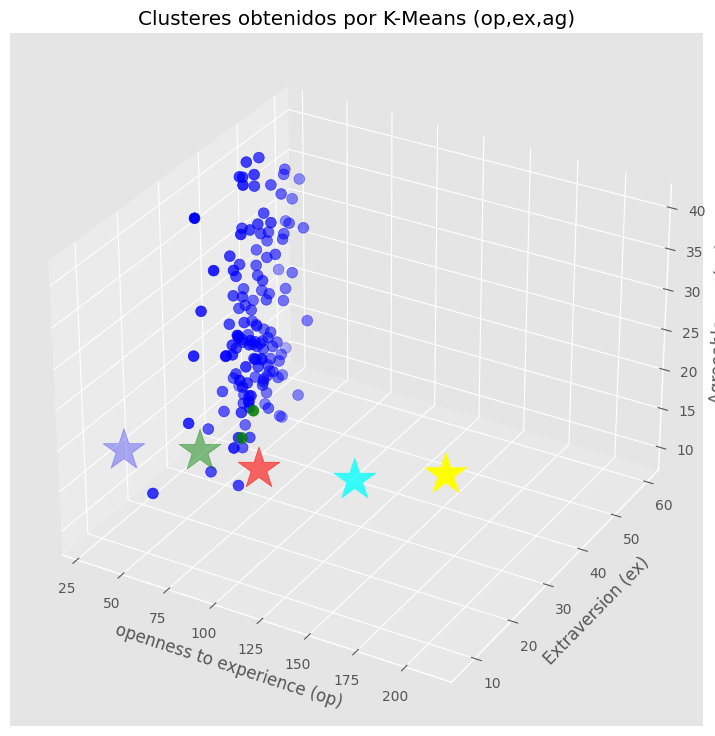

In [15]:
#Prediciendo los clusteres
X=np.array(dataframe[["op","ex","ag"]])
labels=kmeans.predict(X)
#colocando los puntos junto con los clusteres

C=kmeans.cluster_centers_
colores=["blue","red","green","cyan","yellow"]
asignar=[]
for row in labels:
    asignar.append(colores[row])

fig=plt.figure()
ax=fig.add_subplot(111, projection="3d")
ax.scatter(X[:,0],X[:,1],X[:,2],c=asignar,s=60)
ax.scatter(C[:,0],C[:,1],C[:,2],marker="*",color=colores,s=1000)
ax.set_xlabel("openness to experience (op)")
ax.set_ylabel("Extraversion (ex)")
ax.set_zlabel("Agreeableness (ag)")
ax.set_title("Clusteres obtenidos por K-Means (op,ex,ag)")
plt.show()

Se puede observar como KMeans ha agrupado 140 usuarios de twitter en 5 lusteres de acuerdo a la personalidad de openess, extraversion y agreebleness.

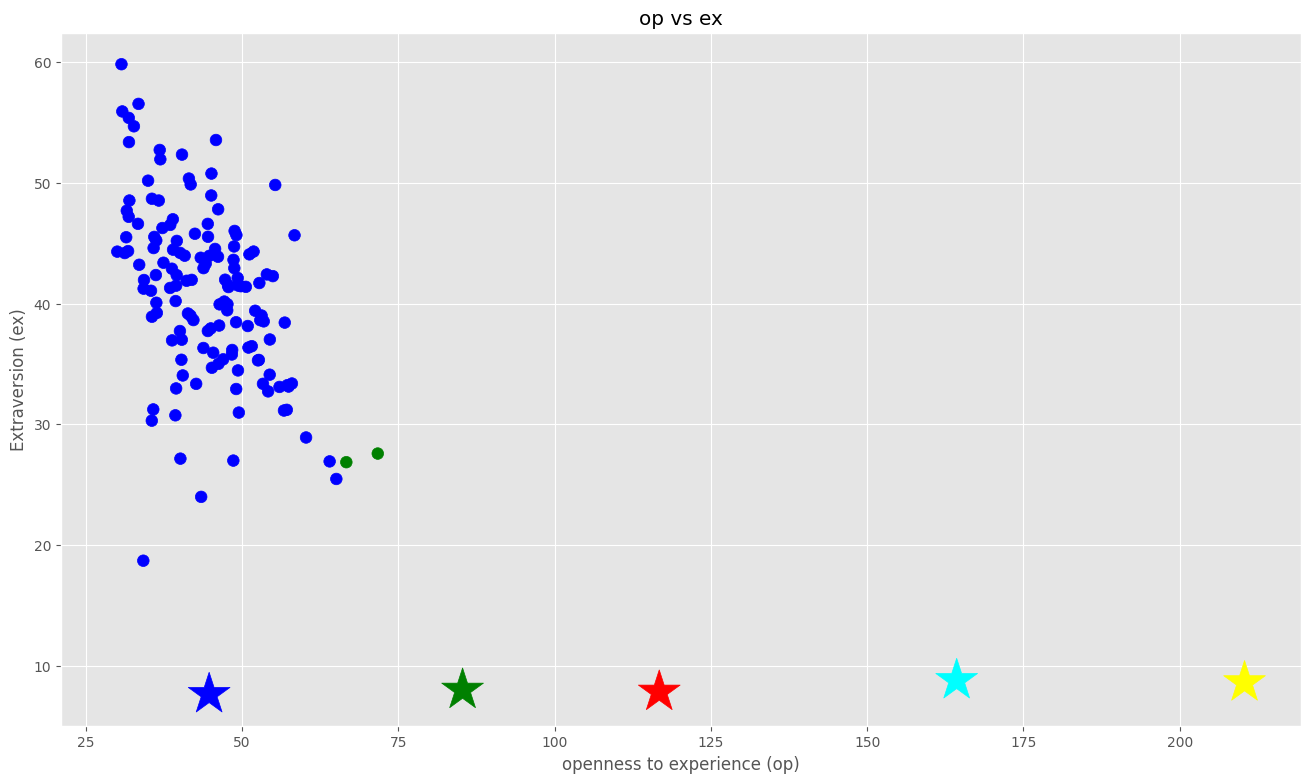

In [16]:
#graficando op vs ex
f1=dataframe["op"].values
f2=dataframe["ex"].values

plt.scatter(f1,f2,c=asignar,s=70)
plt.scatter(C[:,0],C[:,1], marker="*",c=colores, s=1000)
plt.xlabel("openness to experience (op)")
plt.ylabel("Extraversion (ex)")
plt.title("op vs ex")
plt.show()

In [17]:
copy=pd.DataFrame()
copy["usuario"]=dataframe["usuario"].values
copy["categoria"]=dataframe["categoria"].values
copy["label"]=labels;
cantidadGrupo=pd.DataFrame()
cantidadGrupo["Color"]=colores
cantidadGrupo["Cantidad"]=copy.groupby("label").size()
cantidadGrupo

,Color,Cantidad
0,blue,138.0
1,red,NaN
2,green,2.0
3,cyan,NaN
4,yellow,NaN


Para finalizar, se debe categorizar cada grupo con respecto a sus profesiones, para este ejemplo se va a identificar cuantas de esas profesiones pertenecen al cluster rojo (0)

In [18]:
gruop_referrer_index=copy["label"]==0
group_referrer=copy[gruop_referrer_index]

diversidadGrupo=pd.DataFrame()
diversidadGrupo["categoria"]=[0,1,2,3,4,5,6,7,8,9]
diversidadGrupo["cantidad"]=group_referrer.groupby("categoria").size()
diversidadGrupo

,categoria,cantidad
0,0,NaN
1,1,26.0
2,2,33.0
3,3,9.0
4,4,19.0
5,5,4.0
6,6,8.0
7,7,17.0
8,8,16.0
9,9,6.0


In [19]:
closest,_=pairwise_distances_argmin_min(kmeans.cluster_centers_,X)
closest

array([125, 137, 137, 137, 137])

In [20]:
user=dataframe["usuario"].values
for row in closest:
  print(user[row])

SSantiagosegura
xoellopez
xoellopez
xoellopez
xoellopez


In [21]:
X_new=np.array([[45.92,57.74,15.66]]) #agregar a alguien

new_labels=kmeans.predict(X_new)
print(new_labels)

[0]


In [23]:
import numpy as np
from sklearn.metrics import adjusted_rand_score, homogeneity_score, completeness_score, v_measure_score

# El modelo K-Means fue entrenado con 'wordcount', 'ne', 'co'
# Por lo tanto, debemos predecir las etiquetas usando estas mismas características para la evaluación.
X_for_clustering = np.array(dataframe[["wordcount","ne","co"]])
predicted_labels = kmeans.predict(X_for_clustering)

# 'y' representa las categorías verdaderas del dataframe
y_true = np.array(dataframe["categoria"])

# Calcular métricas de evaluación
ar_score = adjusted_rand_score(y_true, predicted_labels)
homogeneity = homogeneity_score(y_true, predicted_labels)
completeness = completeness_score(y_true, predicted_labels)
v_measure = v_measure_score(y_true, predicted_labels)

print(f"Índice Rand Ajustado: {ar_score:.4f}")
print(f"Puntuación de Homogeneidad: {homogeneity:.4f}")
print(f"Puntuación de Completitud: {completeness:.4f}")
print(f"Puntuación V-measure: {v_measure:.4f}")

print("\nInterpretación:")
print("- Índice Rand Ajustado: Mide la similitud entre las asignaciones de clúster verdaderas y predichas, corrigiendo por azar. Una puntuación cercana a 1.0 indica una muy buena agrupación.")
print("- Homogeneidad: Mide si cada clúster contiene solo puntos de datos que pertenecen a una sola clase (categoría). Una puntuación cercana a 1.0 es buena.")
print("- Completitud: Mide si todos los puntos de datos que pertenecen a una clase (categoría) dada son asignados al mismo clúster. Una puntuación cercana a 1.0 es buena.")
print("- V-measure: La media armónica de homogeneidad y completitud. Una puntuación cercana a 1.0 es buena.")

Índice Rand Ajustado: 0.0427
Puntuación de Homogeneidad: 0.0926
Puntuación de Completitud: 0.1292
Puntuación V-measure: 0.1079

Interpretación:
- Índice Rand Ajustado: Mide la similitud entre las asignaciones de clúster verdaderas y predichas, corrigiendo por azar. Una puntuación cercana a 1.0 indica una muy buena agrupación.
- Homogeneidad: Mide si cada clúster contiene solo puntos de datos que pertenecen a una sola clase (categoría). Una puntuación cercana a 1.0 es buena.
- Completitud: Mide si todos los puntos de datos que pertenecen a una clase (categoría) dada son asignados al mismo clúster. Una puntuación cercana a 1.0 es buena.
- V-measure: La media armónica de homogeneidad y completitud. Una puntuación cercana a 1.0 es buena.


##Como conclusion, este ha sido el analizis de los otros 3 parametros del dataset